In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/fassi182/Bank-Marketing-Dataset/refs/heads/main/bank.csv"
df = pd.read_csv(url)


# Data Preprocessing

In [3]:
# Handle missing values
df.replace("unknown", np.nan, inplace=True)
imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


In [4]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)


In [5]:
# Standardize the data using StandardScaler
scaler = StandardScaler()
X = df_encoded.drop('deposit_yes', axis=1)
y = df_encoded['deposit_yes']
X_scaled = scaler.fit_transform(X)

In [6]:
# Feature Selection using SelectKBest
selector = SelectKBest(mutual_info_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)


# Model Training

In [8]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg_score = cross_val_score(log_reg, X_selected, y, cv=5, scoring='accuracy')


In [12]:
# Decision Tree Classifier
dtree = DecisionTreeClassifier()
dtree_score = cross_val_score(dtree, X_selected, y, cv=5, scoring='accuracy')


In [13]:
# Random Forest Classifier
rf = RandomForestClassifier()
rf_score = cross_val_score(rf, X_selected, y, cv=5, scoring='accuracy')


# Evaluation

In [14]:
# Fit models on the entire dataset and evaluate their performance
log_reg.fit(X_selected, y)
dtree.fit(X_selected, y)
rf.fit(X_selected, y)

log_reg_pred = log_reg.predict(X_selected)
dtree_pred = dtree.predict(X_selected)
rf_pred = rf.predict(X_selected)

log_reg_acc = accuracy_score(y, log_reg_pred)
dtree_acc = accuracy_score(y, dtree_pred)
rf_acc = accuracy_score(y, rf_pred)

log_reg_prec = precision_score(y, log_reg_pred)
dtree_prec = precision_score(y, dtree_pred)
rf_prec = precision_score(y, rf_pred)

log_reg_rec = recall_score(y, log_reg_pred)
dtree_rec = recall_score(y, dtree_pred)
rf_rec = recall_score(y, rf_pred)

log_reg_f1 = f1_score(y, log_reg_pred)
dtree_f1 = f1_score(y, dtree_pred)
rf_f1 = f1_score(y, rf_pred)



In [15]:
# Feature Importance (for Random Forest)
feature_importances = rf.feature_importances_


In [16]:
# Visualize Feature Importances
features = X.columns[selector.get_support()]
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


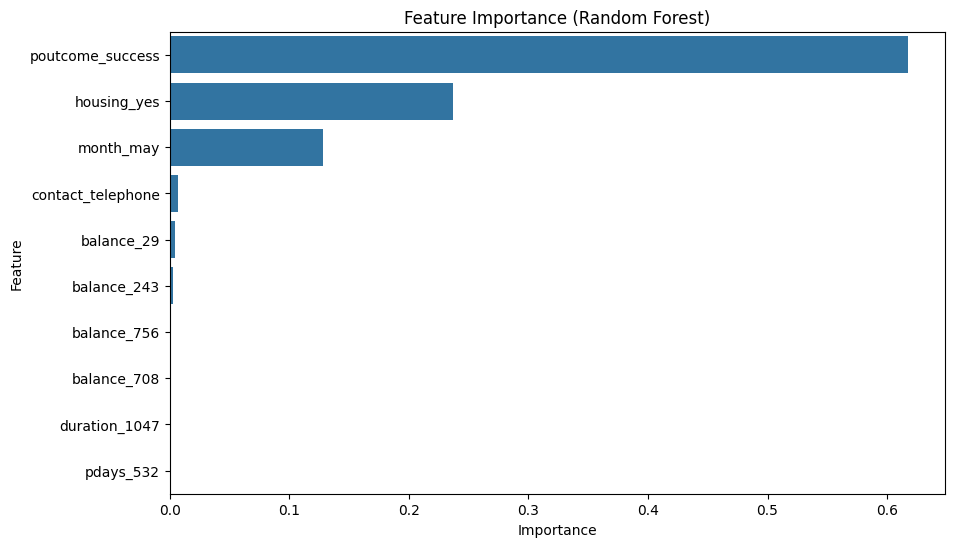

In [17]:
# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [18]:

# Report Results
print("Logistic Regression Accuracy: ", log_reg_acc)
print("Decision Tree Accuracy: ", dtree_acc)
print("Random Forest Accuracy: ", rf_acc)

print("Logistic Regression Precision: ", log_reg_prec)
print("Decision Tree Precision: ", dtree_prec)
print("Random Forest Precision: ", rf_prec)

print("Logistic Regression Recall: ", log_reg_rec)
print("Decision Tree Recall: ", dtree_rec)
print("Random Forest Recall: ", rf_rec)

print("Logistic Regression F1-score: ", log_reg_f1)
print("Decision Tree F1-score: ", dtree_f1)
print("Random Forest F1-score: ", rf_f1)

print("\nFeature Importance Ranking:")
print(importance_df)


Logistic Regression Accuracy:  0.6232753986740728
Decision Tree Accuracy:  0.6235441677118796
Random Forest Accuracy:  0.6235441677118796
Logistic Regression Precision:  0.5937716262975778
Decision Tree Precision:  0.593982362095798
Random Forest Precision:  0.593982362095798
Logistic Regression Recall:  0.6488939307997731
Decision Tree Recall:  0.6494611457742484
Random Forest Recall:  0.6494611457742484
Logistic Regression F1-score:  0.6201102177251784
Decision Tree F1-score:  0.6204841040462428
Random Forest F1-score:  0.6204841040462428

Feature Importance Ranking:
             Feature  Importance
9   poutcome_success    0.617489
4        housing_yes    0.236500
6          month_may    0.128079
5  contact_telephone    0.006808
0         balance_29    0.004610
1        balance_243    0.002865
3        balance_756    0.001270
2        balance_708    0.001042
7      duration_1047    0.000739
8          pdays_532    0.000598
